# 07 — Daily paths for backtesting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/07_daily_paths_for_backtesting.ipynb)

A strategy backtester brings daily returns and wants daily paths. Daily data has
what annual targets do not: volatility clustering and fat tails. With
`dynamics='auto'` the package chooses a model per asset, GARCH family or
Gaussian hidden Markov model, by i.i.d. tests on its residuals, then BIC, with
a bootstrap goodness-of-fit check. The generator is fitted on the standardized
residuals, the C-vine carries the dependence between them, and `simulate_paths`
filters the simulated residuals back through each asset's model from its last
observed state.

Runtime: about an hour (28 candidates and one bootstrap of 100 refits per asset; an HMM winner costs about 20 minutes of refits, and there are three C-vine fits).

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

try:
    import arch
except ImportError:
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "arch"], check=True)
from cvinemarketgen import Targets, CVineMarket, load_daily_returns, exceedance_curve

cvinemarketgen 0.3.0


## Daily returns of four ETFs

SPY (U.S. equity), TLT (long Treasuries), GLD (gold), DBC (commodities), adjusted
closes from Yahoo Finance since 2010, cached in `data/daily_cache.csv`. Any
DataFrame of daily returns works the same way.

The returns are simple daily returns of the adjusted closes (dividends reinvested), $r_t = P_t / P_{t-1} - 1$, aligned on the days where all four trade; about $n = 4{,}200$ days.

In [2]:
daily = load_daily_returns(["SPY", "TLT", "GLD", "DBC"], start="2010-01-01", cache=os.path.join(ROOT, "data", "daily_cache.csv"))
daily.tail()

daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache.csv: 4197 days, 2010-01-05 to 2026-09-11


,SPY,TLT,GLD,DBC
date,,,,
2026-09-04,-0.003854,0.001706,-0.008410,-0.001877
2026-09-08,-0.005492,-0.000122,-0.017332,0.015674
2026-09-09,-0.004648,-0.005718,0.009081,0.013889
2026-09-10,-0.005994,-0.011624,-0.017330,0.023440
2026-09-11,0.008524,0.001114,0.006080,-0.013682


Sample moments at the daily frequency, annualized by $252\,\bar r$ for the mean and $\sqrt{252}\, s$ for the volatility; skewness $\hat\gamma_1$ and raw kurtosis $\hat\gamma_2$ (normal $= 3$) are the bias-adjusted sample estimators and are not annualized. Daily kurtosis above 10 is the signature of fat tails and of volatility clustering together: a mixture of calm and turbulent days has a higher kurtosis than either regime alone.

In [3]:
pd.concat([daily.mean().mul(252).rename("mean (ann.)"), daily.std().mul(252 ** 0.5).rename("vol (ann.)"),
           daily.skew().rename("skew"), (daily.kurtosis() + 3).rename("kurt")], axis=1).round(3)

,mean (ann.),vol (ann.),skew,kurt
SPY,0.147,0.171,-0.329,15.046
TLT,0.034,0.149,0.050,6.586
GLD,0.092,0.168,-0.544,9.012
DBC,0.042,0.174,-0.518,6.412


Volatility clustering is serial dependence in the squares: $\mathrm{Corr}(r_t^2, r_{t-\ell}^2) > 0$ for many lags $\ell$ while $\mathrm{Corr}(r_t, r_{t-\ell}) \approx 0$. It is visible as bursts of large returns of either sign, and it is what an i.i.d. draw from any marginal cannot produce.

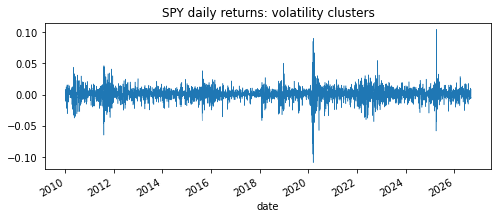

In [4]:
fig, ax = plt.subplots(figsize=(8, 3)); daily["SPY"].plot(ax=ax, lw=0.5); ax.set_title("SPY daily returns: volatility clusters"); plt.show()

## Targets are the sample, at daily frequency

The targets are the sample moments of the daily returns, $\mu_i = \bar r_i$, $\sigma_i = s_i$, $\gamma_{1,i} = \hat\gamma_{1,i}$, $\gamma_{2,i} = \hat\gamma_{2,i}$, $\Sigma^* = \hat\Sigma$, in daily units, and the history is kept. With dynamics the generator will not be fitted on these targets directly but on those of the residual layer, computed inside `fit`.

In [5]:
t = Targets.from_history(daily)
print(t, "| frequency:", t.freq)

Targets(4 assets: SPY, TLT, GLD, DBC; layer=returns) | frequency: None


## Choose the dynamics per asset

Candidates: a constant or AR(1) mean with a constant, GARCH, GJR or EGARCH
variance of orders up to (2, 2), and a Gaussian HMM with two or three regimes,
28 in all. Each candidate is fitted and its residual layer is tested for
independence: Ljung-Box on the residuals, Ljung-Box on their squares, Engle's
ARCH-LM. Among the candidates that pass all three at 5 %, the lowest BIC wins;
the selected model then gets a parametric-bootstrap Cramér-von Mises test of
its Rosenblatt uniforms (`gof_pvalue`). The targets of the residual layer are
the sample moments of the selected residuals; the copula families are selected
on them.

The mathematics of the selection, for one asset with returns $r_t$, $t = 1, \dots, n$.

**Candidates.** Each candidate is a filter $\Psi$ that maps the returns to a residual layer $\varepsilon_t$ that should be i.i.d. The GARCH family has a mean equation, $r_t = c + \epsilon_t$ (constant) or $r_t = c + \phi\, r_{t-1} + \epsilon_t$ (AR(1)), and a variance equation for $\epsilon_t = \sigma_t \varepsilon_t$ with orders $(p, q)$, $p, q \in \{1, 2\}$:
$$\text{GARCH:}\quad \sigma_t^2 = \omega + \sum_{i=1}^{p} \alpha_i\, \epsilon_{t-i}^2 + \sum_{j=1}^{q} \beta_j\, \sigma_{t-j}^2, \qquad \text{GJR:}\quad \sigma_t^2 = \omega + \sum_i \alpha_i\, \epsilon_{t-i}^2 + \gamma\, \epsilon_{t-1}^2\, \mathbf 1\{\epsilon_{t-1} < 0\} + \sum_j \beta_j\, \sigma_{t-j}^2,$$
$$\text{EGARCH:}\quad \log \sigma_t^2 = \omega + \sum_i \alpha_i \big(|z_{t-i}| - \sqrt{2/\pi}\big) + \sum_j \beta_j \log \sigma_{t-j}^2, \quad z_t = \epsilon_t / \sigma_t ,$$
plus the constant-variance case $\sigma_t^2 = \omega$. They are estimated by Gaussian maximum likelihood with the `arch` package on $100\, r_t$; the residual layer is $\varepsilon_t = \epsilon_t / \sigma_t$. The Gaussian hidden Markov model with $K \in \{2, 3\}$ regimes has $r_t \mid S_t = k \sim N(\mu_k, \sigma_k^2)$ and a Markov chain $S_t$ with transition matrix $Q$; estimated by EM (GenHMM1d), its residual layer is the normal score of the Rosenblatt uniform of the one-step predictive mixture,
$$U_t = \sum_{k=1}^{K} \Pr(S_t = k \mid r_{1:t-1})\; \Phi\!\Big(\frac{r_t - \mu_k}{\sigma_k}\Big), \qquad \varepsilon_t = \Phi^{-1}(U_t),$$
with $\Pr(S_t = \cdot \mid r_{1:t-1}) = \boldsymbol\eta_{t-1}' Q$ and $\boldsymbol\eta_{t-1}$ the filtered probabilities. Two means, four variance models with up to four orders, and two regime counts give the 28 candidates.

**Tests.** On each residual layer, with $m = 20$ lags and $\hat\rho_\ell$ the sample autocorrelation at lag $\ell$: the Ljung-Box statistic $Q = n(n+2) \sum_{\ell=1}^{m} \hat\rho_\ell^2 / (n - \ell) \sim \chi^2_m$ on $\varepsilon_t$ and again on $\varepsilon_t^2$, and Engle's ARCH-LM statistic $n R^2 \sim \chi^2_m$ from the regression of $\varepsilon_t^2$ on its $m$ lags. A candidate passes when all three $p$-values exceed $\alpha = 0.05$.

**Selection.** Among the passers, the lowest $\mathrm{BIC} = k \ln n - 2\,\ell$ wins, with $k$ the number of parameters and $\ell$ the log-likelihood on the data's own scale (the `arch` likelihood of $100\, r_t$ is corrected by $-n \ln 100$, so that GARCH and HMM are comparable); if no candidate passes, the lowest BIC overall is kept and the report says so (`passed`).

**Goodness of fit.** The winner gets a parametric-bootstrap Cramér-von Mises test on its uniforms $v_t = \Phi(\varepsilon_t)$: the statistic $W = \frac{1}{12 n} + \sum_{i=1}^{n} \big(v_{(i)} - \frac{i - 0.5}{n}\big)^2$ on the sample, against the same statistic on $B = 100$ series simulated from the fitted model and refitted; `gof_pvalue` is the share of bootstrap statistics above the sample's. It tests the Gaussian innovation of the fitted model, not the Johnson SU marginal the generator will put on the residual layer, and small $p$-values are expected on 4,000 fat-tailed days.

The report has one row per asset: the winner, its BIC, the three $p$-values, whether it passed, the goodness-of-fit $p$-value and the counts of passers and candidates.

In [6]:
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto", dynamics="auto", dynamics_kwargs=dict(B=100, seed=0, verbose=False)).fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.dynamics_report[["model", "bic", "lb_z", "lb_z2", "arch_lm", "passed", "gof_pvalue", "n_passed", "n_candidates"]].round(3)

fit: 1947 s


,model,bic,lb_z,lb_z2,arch_lm,passed,gof_pvalue,n_passed,n_candidates
asset,,,,,,,,,
SPY,"Const-GJR(1,1)",-28024.483,0.20,0.914,0.926,True,0.0,24,28
TLT,"Const-GARCH(1,1)",-27935.841,0.27,0.850,0.881,True,0.0,25,28
GLD,"Const-GJR(1,1)",-26955.246,0.97,0.589,0.640,True,0.0,24,28
DBC,HMM(3),-26592.344,0.42,0.428,0.424,True,0.0,25,28


## The candidates of one asset

Every fit is kept in `cv.dynamics.candidates`. For SPY, the ten best by BIC:

The full candidate table for SPY sorted by BIC: `n_params` is $k$, `bic` is $k \ln n - 2\ell$ on the data's scale, the three columns are the $p$-values of the Ljung-Box tests on $\varepsilon_t$ and $\varepsilon_t^2$ and of the ARCH-LM test, and `passed` says whether all three exceed $0.05$. The winner is the first passing row, not necessarily the first row.

In [7]:
c = cv.dynamics.candidates
c[c["asset"] == "SPY"].sort_values("bic")[["model", "n_params", "bic", "lb_z", "lb_z2", "arch_lm", "passed"]].head(10).round(3)

,model,n_params,bic,lb_z,lb_z2,arch_lm,passed
10,"Const-GJR(1,1)",5,-28024.483,0.200,0.914,0.926,True
12,"Const-GJR(2,1)",6,-28018.294,0.210,0.940,0.947,True
11,"Const-GJR(1,2)",6,-28016.140,0.200,0.914,0.926,True
14,"AR(1)-GJR(1,1)",6,-28012.482,0.209,0.926,0.935,True
13,"Const-GJR(2,2)",7,-28009.952,0.210,0.940,0.947,True
16,"AR(1)-GJR(2,1)",7,-28006.552,0.217,0.951,0.956,True
15,"AR(1)-GJR(1,2)",7,-28004.140,0.209,0.926,0.935,True
17,"AR(1)-GJR(2,2)",8,-27998.210,0.217,0.951,0.956,True
2,"Const-GARCH(1,1)",4,-27867.188,0.135,0.774,0.805,True
4,"Const-GARCH(2,1)",5,-27864.099,0.153,0.897,0.909,True


## The residual layer and its vine

`edges` and `marginals` describe the residual layer.

With dynamics, the generator is fitted on the residual layer: its targets are the sample moments of the selected residuals $\varepsilon_{i,t}$ of each asset, mean, volatility (both near $0$ and $1$), skewness, kurtosis, and their correlation matrix. A kurtosis at or below $3$ is floored at $3.1 + 2\gamma_1^2$, the boundary of the Johnson SU family, with a warning. The C-vine is then selected and calibrated on these residual targets exactly as on returns: exceedance-correlation signatures on the residual history, lowest-BIC family per edge, and the correlation-matching calibration $\hat{\boldsymbol\theta}_i = \arg\min \sum_{k<i} (\mathrm{Corr}(F_i^{-1}(u_i), F_k^{-1}(u_k)) - \Sigma^*_{ik})^2$. `edges` lists the result.

In [8]:
cv.edges

,tree,edge,selected family,parameters
0,1,"TLT , SPY",gumbel 90°,theta=1.154
1,1,"GLD , SPY",gumbel 0°,theta=1.066
2,1,"DBC , SPY",gumbel 180°,theta=1.249
3,2,"GLD , TLT | SPY",gaussian 0°,theta=0.274
4,2,"DBC , TLT | SPY",gaussian 0°,theta=-0.151
5,3,"DBC , GLD | SPY, TLT",gaussian 0°,theta=0.389


`fit_targets` are those residual-layer targets: means near $0$, volatilities near $1$, the skewness and kurtosis of the standardized residuals, and their correlations, which are smaller than the return correlations when the volatility clustering was common to the assets.

In [9]:
cv.fit_targets.summary();

Targets for 4 assets (residuals layer)
       mean     vol    skew    kurt
SPY -0.0057  0.9998 -0.6831  5.4563
TLT  0.0032  1.0002 -0.0939  3.6674
GLD  0.0029  1.0003 -0.2949  5.4772
DBC -0.0068  0.9935 -0.1455  3.1424

correlation matrix:
      SPY   TLT   GLD   DBC
SPY  1.00 -0.24  0.07  0.33
TLT -0.24  1.00  0.24 -0.22
GLD  0.07  0.24  1.00  0.31
DBC  0.33 -0.22  0.31  1.00

skewness and kurtosis: estimated from the history (4197 observations)


## Simulate 1,000 daily paths of one year

`Paths` holds an array `(n_paths, horizon, N)`; `to_frame()` gives the long
table a backtester loops over, `wide(asset)` one asset across paths,
`terminal()` the cumulative return at the horizon.

Path simulation is the algorithm of the path-simulation paper, run here with $S = 1{,}000$ paths and $h = 252$ days.

1. Draw $S \times h$ residual vectors from the calibrated vine and its Johnson SU marginals (no accept-reject on this large pool) and reshape them into $\varepsilon^{(s)}_{i,t}$, $s = 1..S$, $t = 1..h$: on every day the residuals of the four assets have the vine as copula.
2. For each asset, apply the inverse filter $\Psi^{-1}$ from the last observed state. For the GARCH family the state is the last return, the last $p$ innovations and the last $q$ variances, and the recursion is
$$\sigma_t^2 = \omega + \sum_i \alpha_i\, \epsilon_{t-i}^2 (+\, \gamma\, \epsilon_{t-1}^2 \mathbf 1\{\epsilon_{t-1} < 0\}) + \sum_j \beta_j\, \sigma_{t-j}^2, \qquad \epsilon_t = \sigma_t\, \varepsilon_t, \qquad r_t = c + \phi\, r_{t-1} + \epsilon_t ,$$
(EGARCH in logs). For the HMM the state is the filtered probability vector $\boldsymbol\eta_T$, and each step inverts the predictive mixture, $r_t = G_t^{-1}(\Phi(\varepsilon_t))$ with $G_t(y) = \sum_k (\boldsymbol\eta_{t-1}' Q)_k\, \Phi((y - \mu_k)/\sigma_k)$ solved by bisection, then updates $\boldsymbol\eta_t$ by the forward recursion.
3. Both inverses are exact: filtering the simulated path returns the drawn residuals to machine precision.

The result is a `Paths` array of shape $(S, h, N)$; `to_frame` stacks it as a long table indexed by path and day.

In [10]:
t0 = time.time()
P = cv.simulate_paths(n_paths=1000, horizon=252, seed=1)
print(P, f"({time.time() - t0:.0f} s)")
P.to_frame().head()

Paths(n_paths=1000, horizon=252, assets=4, returns) (34 s)


SPY       TLT       GLD       DBC
path t                                        
0    1 -0.000269  0.003729 -0.083392 -0.022549
     2 -0.006029 -0.007127 -0.028120 -0.010442
     3 -0.000623  0.000919 -0.002972  0.003604
     4 -0.004397  0.008082 -0.035104 -0.007779
     5 -0.000249  0.001142 -0.020397 -0.012004

The pooled per-day moments of the paths against the history: the selected dynamics restore the fat tails and the serial dependence.

Pooled moments of the $S \times h$ simulated days against the moments of the history: with the dynamics, the unconditional kurtosis of the paths is the kurtosis of the residual layer amplified by the volatility process. For a GARCH(1,1) with innovation kurtosis $\kappa_\varepsilon$ and persistence $\alpha + \beta$ the unconditional kurtosis is
$$\kappa_r = \kappa_\varepsilon\, \frac{1 - (\alpha + \beta)^2}{1 - (\alpha + \beta)^2 - (\kappa_\varepsilon - 1)\,\alpha^2},$$
finite only when the denominator is positive; when it is not (as for SPY's GJR fit), the pooled sample kurtosis is large and unstable across draws, and it should be read as such.

In [11]:
pd.concat([P.summary().add_suffix(" (paths)"), t.moments.add_suffix(" (history)")], axis=1).round(5)

,mean (paths),vol (paths),skew (paths),kurt (paths),mean (history),vol (history),skew (history),kurt (history)
SPY,0.00047,0.01164,-1.27017,44.24311,0.00058,0.01075,-0.32940,15.04617
TLT,0.00014,0.00865,-0.07970,5.12513,0.00014,0.00939,0.04990,6.58560
GLD,0.00035,0.01183,-0.37784,8.60626,0.00036,0.01056,-0.54381,9.01242
DBC,0.00001,0.01115,-0.60014,6.71002,0.00017,0.01097,-0.51780,6.41195


Cumulative paths $\prod_{u \le t} (1 + r^{(s)}_u) - 1$ for fifty of the $S$ paths, and the distribution across paths of the one-year terminal return $\prod_{u=1}^{h} (1 + r^{(s)}_u) - 1$, with its quantiles: the object a backtester or a risk manager reads off the paths.

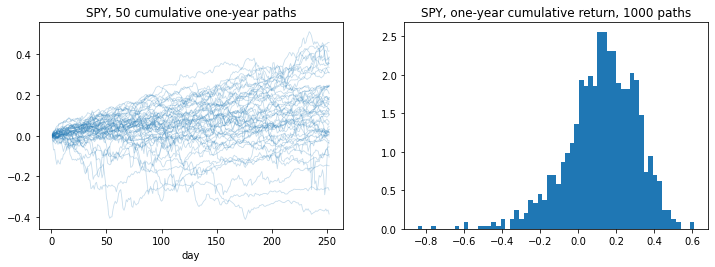

,SPY,TLT,GLD,DBC
0.01,-0.428,-0.232,-0.378,-0.426
0.05,-0.202,-0.175,-0.218,-0.305
0.50,0.138,0.025,0.074,0.003
0.95,0.395,0.277,0.459,0.325
0.99,0.477,0.423,0.780,0.488


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(P.cumulative().wide("SPY").iloc[:, :50], color="tab:blue", alpha=0.25, lw=0.8); axes[0].set_title("SPY, 50 cumulative one-year paths"); axes[0].set_xlabel("day")
axes[1].hist(P.terminal()["SPY"], bins=60, density=True); axes[1].set_title("SPY, one-year cumulative return, 1000 paths"); plt.show()
P.terminal().quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(3)

## Why the dynamics matter

The same vine without dynamics (`dynamics=None`) gives i.i.d. days, and the
previous version of this notebook used a fixed AR(1)-GARCH(1,1) for every asset
(`dynamics='ar1-garch'`, still available). All three match the unconditional
moments of the history, kurtosis included, because the marginals are fitted to
them. What the i.i.d. version cannot have is volatility clustering: the
autocorrelation of squared returns, which is what a daily backtest lives on.
Compare the three, then look at one simulated year of each.

The measure of volatility clustering is the autocorrelation of squared returns at lag $\ell$,
$$\hat\rho_{r^2}(\ell) = \frac{\sum_t (r_t^2 - \overline{r^2})(r_{t-\ell}^2 - \overline{r^2})}{\sum_t (r_t^2 - \overline{r^2})^2},$$
computed on the history and, for the paths, on each of 200 simulated years and averaged. Three markets are compared on it: `dynamics=None` (i.i.d. days, $\hat\rho_{r^2}(\ell) = 0$ in expectation), a fixed AR(1)-GARCH(1,1) for every asset, and the selected dynamics.

In [13]:
cv0 = CVineMarket(t, central="SPY", families="auto").fit()
P0 = cv0.simulate_paths(n_paths=1000, horizon=252, seed=2)
cv_fixed = CVineMarket(t, central="SPY", families="auto", dynamics="ar1-garch").fit()
Pf = cv_fixed.simulate_paths(n_paths=1000, horizon=252, seed=2)

def acf_sq(x, lags=(1, 5, 20)):
    x2 = pd.Series(np.asarray(x) ** 2)
    return pd.Series({f"lag {l}": x2.autocorr(l) for l in lags})

def acf_sq_paths(P, asset, lags=(1, 5, 20)):
    j = P.assets.index(asset)
    return pd.concat([acf_sq(P.array[i, :, j], lags) for i in range(200)], axis=1).mean(axis=1)

pd.DataFrame({"history": acf_sq(daily["SPY"]), "i.i.d. paths": acf_sq_paths(P0, "SPY"),
              "fixed AR(1)-GARCH(1,1)": acf_sq_paths(Pf, "SPY"), "selected dynamics": acf_sq_paths(P, "SPY")}).round(3)

,history,i.i.d. paths,"fixed AR(1)-GARCH(1,1)",selected dynamics
lag 1,0.401,0.002,0.167,0.178
lag 5,0.266,-0.003,0.116,0.125
lag 20,0.100,-0.008,0.025,0.032


The pooled kurtosis $\hat\gamma_2 = \frac{1}{Sh}\sum_{s,t}\big((r^{(s)}_t - \bar r)/s\big)^4$ over all simulated days of the three markets, against the history's: the i.i.d. market matches the historical kurtosis by construction (the marginal is fitted to it), the GARCH markets get theirs from the residual kurtosis amplified by the variance process, which can overshoot when the process has no finite fourth moment.

In [14]:
pd.DataFrame({"kurt, i.i.d. paths": P0.summary()["kurt"], "kurt, fixed GARCH": Pf.summary()["kurt"],
              "kurt, selected dynamics": P.summary()["kurt"], "kurt, history": t.kurt}).round(2)

,"kurt, i.i.d. paths","kurt, fixed GARCH","kurt, selected dynamics","kurt, history"
SPY,15.05,15.82,44.24,15.05
TLT,6.59,5.32,5.13,6.59
GLD,9.01,8.91,8.61,9.01
DBC,6.41,12.32,6.71,6.41


One simulated year of SPY under each market: with i.i.d. days the large returns are spread uniformly over the year; with a GARCH filter they cluster, $\sigma_t^2$ rising after a large $\epsilon_{t-1}$ and decaying at the rate $\alpha + \beta$.

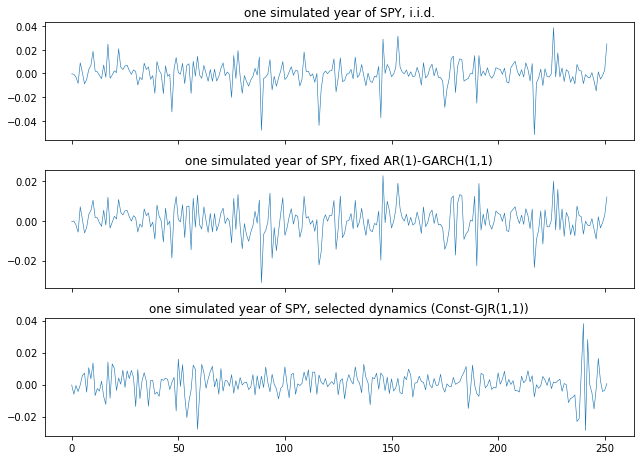

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(P0.array[0, :, 0], lw=0.6); axes[0].set_title("one simulated year of SPY, i.i.d.")
axes[1].plot(Pf.array[0, :, 0], lw=0.6); axes[1].set_title("one simulated year of SPY, fixed AR(1)-GARCH(1,1)")
axes[2].plot(P.array[0, :, 0], lw=0.6); axes[2].set_title(f"one simulated year of SPY, selected dynamics ({cv.dynamics_report.loc['SPY', 'model']})")
plt.tight_layout(); plt.show()

## Save the fitted model, reload it later without refitting

The JSON keeps everything a path needs: the residual-layer targets, the marginal parameters, the vine's families and parameters, and each asset's model with its last state (the last return, innovations and variances for a GARCH model, $\boldsymbol\eta_T$ for an HMM), so that `load` simulates from the same starting point without refitting.

In [16]:
cv.save("daily_market.json")
CVineMarket.load("daily_market.json").simulate_paths(5, 10, seed=1)

Paths(n_paths=5, horizon=10, assets=4, returns)